In [59]:
# Part B: Dataset Understanding & Preparation

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("house_price.csv")

# Display first 5 rows
print("First 5 rows:")
print(df.head())


First 5 rows:
   house_id  area_sqft  bedrooms  bathrooms  location_score  age_years  \
0    100001       1973         5          4             7.6         23   
1    100002       1560         3          3             6.3         13   
2    100003       2071         4          3             5.8          9   
3    100004       2640         5          3             7.7         12   
4    100005       1498         3          3             3.8         15   

   distance_city_km  lot_size_sqft  has_garage  has_pool  \
0              11.9           5220           1         0   
1              15.8           3882           1         0   
2              21.1           4488           0         0   
3               7.9           3614           1         1   
4              24.0           2663           0         0   

   renovation_years_ago  house_price_inr  
0                     0         40275084  
1                    13         26812029  
2                     9         29315677  
3       

In [61]:
# Shape of dataset
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
df.describe()

Shape of dataset: (4200, 12)

Columns:
Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage',
       'has_pool', 'renovation_years_ago', 'house_price_inr'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,102100.500000,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,1212.579894,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,100001.000000,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,101050.750000,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,102100.500000,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,103150.250000,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,104200.000000,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


In [62]:
# Task 7: Independent and Dependent Variables

In [63]:
X = df[
    [
        "area_sqft",
        "bedrooms",
        "bathrooms",
        "location_score",
        "age_years"
    ]
]

# Dependent variable (Target)
y = df["house_price_inr"]

print("\nIndependent Variables:")
print(X.columns.tolist())

print("\nDependent Variable:")
print(y.name)



Independent Variables:
['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years']

Dependent Variable:
house_price_inr


In [64]:
# Task 8: Visualize relationships

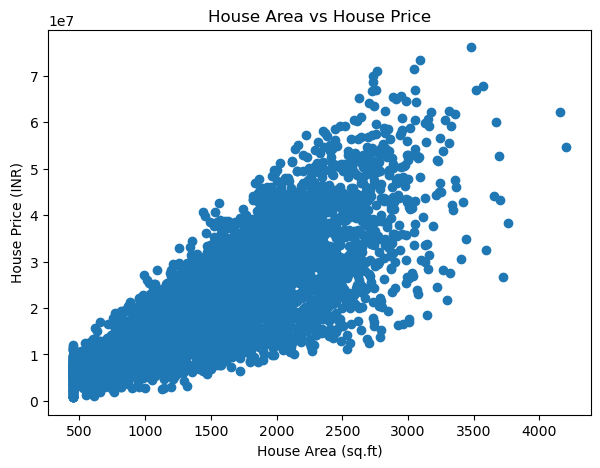

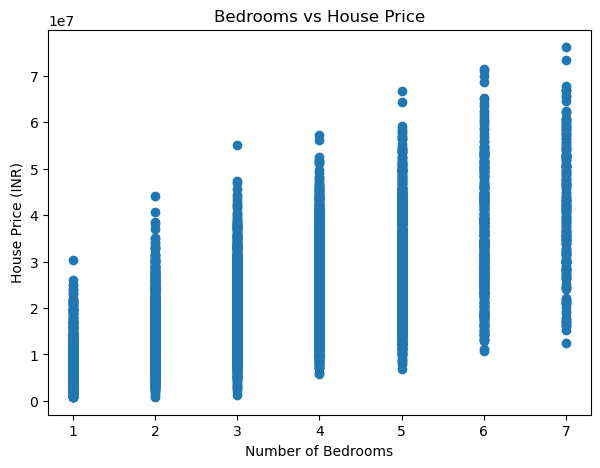

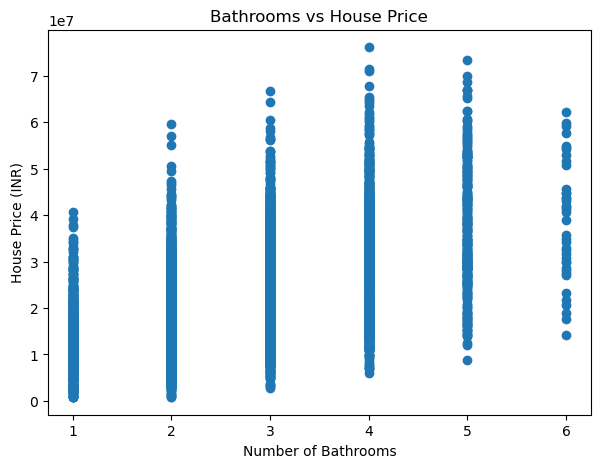

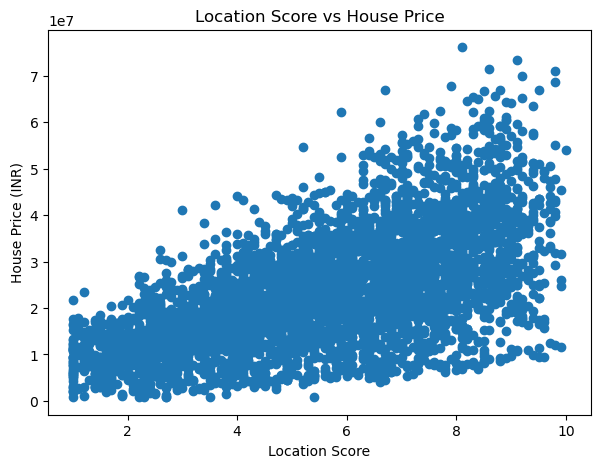

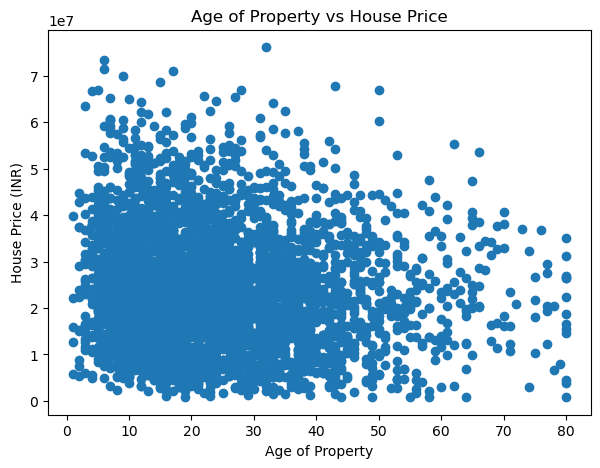

In [65]:
# House Area vs House Price
plt.figure(figsize=(7, 5))
plt.scatter(df["area_sqft"], df["house_price_inr"])
plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price (INR)")
plt.title("House Area vs House Price")
plt.show()


# Bedrooms vs House Price
plt.figure(figsize=(7, 5))
plt.scatter(df["bedrooms"], df["house_price_inr"])
plt.xlabel("Number of Bedrooms")
plt.ylabel("House Price (INR)")
plt.title("Bedrooms vs House Price")
plt.show()


# Bathrooms vs House Price
plt.figure(figsize=(7, 5))
plt.scatter(df["bathrooms"], df["house_price_inr"])
plt.xlabel("Number of Bathrooms")
plt.ylabel("House Price (INR)")
plt.title("Bathrooms vs House Price")
plt.show()


# Location Score vs House Price
plt.figure(figsize=(7, 5))
plt.scatter(df["location_score"], df["house_price_inr"])
plt.xlabel("Location Score")
plt.ylabel("House Price (INR)")
plt.title("Location Score vs House Price")
plt.show()


# Age vs House Price
plt.figure(figsize=(7, 5))
plt.scatter(df["age_years"], df["house_price_inr"])
plt.xlabel("Age of Property")
plt.ylabel("House Price (INR)")
plt.title("Age of Property vs House Price")
plt.show()


In [66]:
# Task 9: Training and Testing Split

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)




Training data: (3360, 5)
Testing data: (840, 5)


In [68]:
# Task 10: Simple Linear Regression
# Using only House Area

In [69]:
X_simple = df[["area_sqft"]]
y_simple = df["house_price_inr"]

# Split data
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple,
    y_simple,
    test_size=0.20,
    random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train_simple, y_train_simple)

# Prediction
y_pred = model.predict(X_test_simple)

print("\nSimple Linear Regression")
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)



Simple Linear Regression
Slope: 14788.306111307533
Intercept: -1163519.1764185987


In [70]:
# Task 11: Regression Line

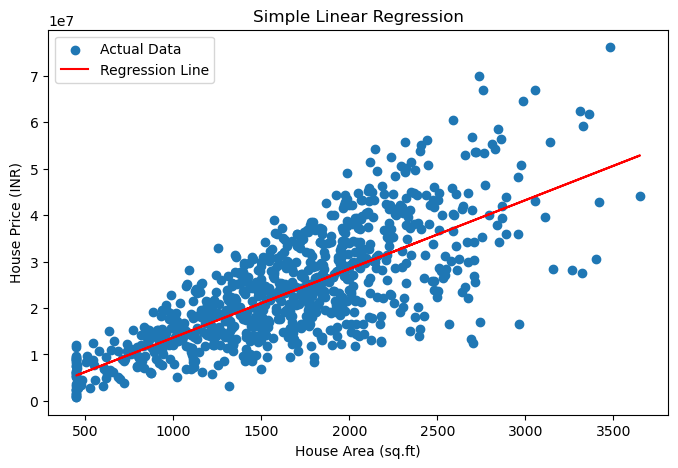

In [71]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_simple["area_sqft"],
    y_test_simple,
    label="Actual Data"
)

plt.plot(
    X_test_simple["area_sqft"],
    y_pred,
    color="red",
    label="Regression Line"
)

plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price (INR)")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()


In [72]:
# Task 12: Validate Linear Regression

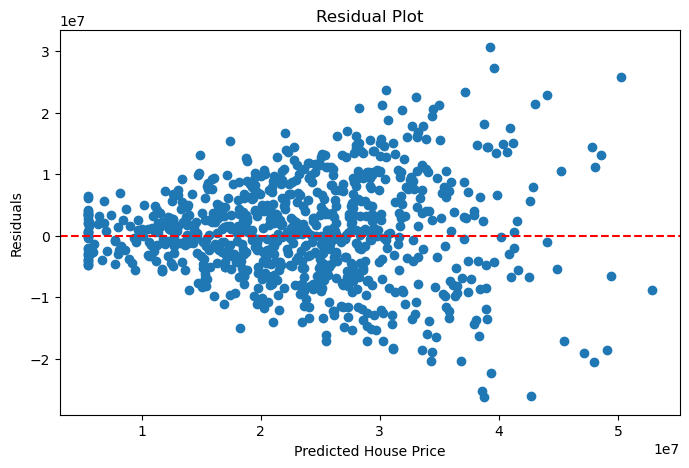

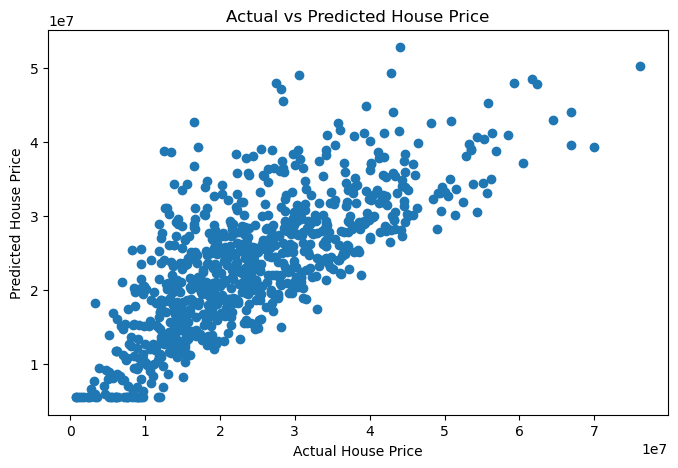

In [73]:
# Residuals
residuals = y_test_simple - y_pred

# Residual plot
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


# Actual vs Predicted
plt.figure(figsize=(8, 5))

plt.scatter(y_test_simple, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Price")
plt.show()

In [74]:
# PART D: MODEL EVALUATION

In [75]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

# Predictions from Simple Linear Regression
y_pred = model.predict(X_test_simple)

# Calculate metrics
mse = mean_squared_error(y_test_simple, y_pred)
mae = mean_absolute_error(y_test_simple, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_simple, y_pred)

# Adjusted R²
n = len(y_test_simple)       # Number of observations
p = X_test_simple.shape[1]   # Number of predictors

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))


# Display results
print("===== Simple Linear Regression =====")
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)
print("Adjusted R² Score:", adjusted_r2)

===== Simple Linear Regression =====
MSE: 66989260021849.47
MAE: 6294593.696131912
RMSE: 8184696.696997969
R² Score: 0.5625199587991578
Adjusted R² Score: 0.5619979062440257


In [76]:
# TASK 14: Interpretation of Evaluation Metrics

print("=" * 60)
print("TASK 14: INTERPRETATION OF EVALUATION METRICS")
print("=" * 60)

print("\n1. Mean Squared Error (MSE)")
print("MSE calculates the average squared difference between")
print("actual and predicted house prices.")
print("Lower MSE means better model performance.")
print("Large errors are penalized more because errors are squared.")

print("\n2. Mean Absolute Error (MAE)")
print("MAE calculates the average absolute difference between")
print("actual and predicted house prices.")
print("Lower MAE means better predictions.")
print("MAE is expressed in the same units as the target variable.")

print("\n3. Root Mean Squared Error (RMSE)")
print("RMSE is the square root of MSE.")
print("Lower RMSE means better prediction performance.")
print("RMSE is expressed in the same units as house price.")
print("It gives more importance to large prediction errors.")

print("\n4. R^2 Score")
print("R^2 measures how much variation in house prices is")
print("explained by the regression model.")
print("R^2 close to 1 -> very good fit.")
print("R^2 close to 0 -> weak explanatory power.")
print("Higher R^2 generally indicates better performance.")

print("\n5. Adjusted R^2")
print("Adjusted R^2 is a modified version of R^2.")
print("It considers the number of predictors in the model.")
print("It can increase when useful features are added.")
print("It can decrease when unnecessary features are added.")
print("It is useful for comparing models with different numbers")
print("of independent variables.")

print("\nCONCLUSION")
print("A good regression model should generally have:")
print("- Low MSE")
print("- Low MAE")
print("- Low RMSE")
print("- High R^2")
print("- High Adjusted R^2")

TASK 14: INTERPRETATION OF EVALUATION METRICS

1. Mean Squared Error (MSE)
MSE calculates the average squared difference between
actual and predicted house prices.
Lower MSE means better model performance.
Large errors are penalized more because errors are squared.

2. Mean Absolute Error (MAE)
MAE calculates the average absolute difference between
actual and predicted house prices.
Lower MAE means better predictions.
MAE is expressed in the same units as the target variable.

3. Root Mean Squared Error (RMSE)
RMSE is the square root of MSE.
Lower RMSE means better prediction performance.
RMSE is expressed in the same units as house price.
It gives more importance to large prediction errors.

4. R^2 Score
R^2 measures how much variation in house prices is
explained by the regression model.
R^2 close to 1 -> very good fit.
R^2 close to 0 -> weak explanatory power.
Higher R^2 generally indicates better performance.

5. Adjusted R^2
Adjusted R^2 is a modified version of R^2.
It considers 

In [77]:
# PART E: MULTIPLE LINEAR REGRESSION

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features
features = [
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "location_score",
    "age_years",
    "distance_city_km",
    "lot_size_sqft",
    "renovation_years_ago"
]

X_multiple = df[features]
y_multiple = df["house_price_inr"]

# Train-test split
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multiple,
    y_multiple,
    test_size=0.20,
    random_state=42
)

# Create model
multiple_model = LinearRegression()

# Train model
multiple_model.fit(X_train_multi, y_train_multi)

# Prediction
y_pred_multi = multiple_model.predict(X_test_multi)

print("Multiple Linear Regression completed!")

# Coefficients
print("\nCoefficients:")

for feature, coefficient in zip(
    features,
    multiple_model.coef_
):
    print(feature, "=", coefficient)

print("\nIntercept:", multiple_model.intercept_)

Multiple Linear Regression completed!

Coefficients:
area_sqft = 13785.580071358478
bedrooms = 207108.2911723641
bathrooms = 184179.95921029564
location_score = 3085527.805712183
age_years = -65613.56334400055
distance_city_km = -98963.94401473776
lot_size_sqft = 104.56076261392234
renovation_years_ago = -21401.53796718469

Intercept: -14747155.213186268


In [79]:
# Task 16 — Compare Simple vs Multiple Regression

In [80]:
# Simple Regression metrics
simple_mse = mean_squared_error(y_test_simple, y_pred)
simple_mae = mean_absolute_error(y_test_simple, y_pred)
simple_rmse = np.sqrt(simple_mse)
simple_r2 = r2_score(y_test_simple, y_pred)

n_simple = len(y_test_simple)
p_simple = X_test_simple.shape[1]

simple_adj_r2 = 1 - (
    (1 - simple_r2) *
    (n_simple - 1) /
    (n_simple - p_simple - 1)
)


# Multiple Regression metrics
multi_mse = mean_squared_error(y_test_multi, y_pred_multi)
multi_mae = mean_absolute_error(y_test_multi, y_pred_multi)
multi_rmse = np.sqrt(multi_mse)
multi_r2 = r2_score(y_test_multi, y_pred_multi)

n_multi = len(y_test_multi)
p_multi = X_test_multi.shape[1]

multi_adj_r2 = 1 - (
    (1 - multi_r2) *
    (n_multi - 1) /
    (n_multi - p_multi - 1)
)


# Display comparison
print("\n================================")
print("MODEL COMPARISON")
print("================================")

print("\nSimple Linear Regression:")
print("MSE:", simple_mse)
print("MAE:", simple_mae)
print("RMSE:", simple_rmse)
print("R²:", simple_r2)
print("Adjusted R²:", simple_adj_r2)


print("\nMultiple Linear Regression:")
print("MSE:", multi_mse)
print("MAE:", multi_mae)
print("RMSE:", multi_rmse)
print("R²:", multi_r2)
print("Adjusted R²:", multi_adj_r2)


MODEL COMPARISON

Simple Linear Regression:
MSE: 66989260021849.47
MAE: 6294593.696131912
RMSE: 8184696.696997969
R²: 0.5625199587991578
Adjusted R²: 0.5619979062440257

Multiple Linear Regression:
MSE: 12605343634682.467
MAE: 2606586.9874642175
RMSE: 3550400.4893367263
R²: 0.917679546678781
Adjusted R²: 0.9168870513399486


In [81]:
 # TASK 17: Why Performance Improves or Degrades

print("=" * 60)
print("TASK 17: WHY PERFORMANCE IMPROVES OR DEGRADES")
print("=" * 60)

print("\nMultiple Linear Regression can perform better than")
print("Simple Linear Regression because it uses multiple features.")

print("\nWhy performance can improve:")
print("1. More relevant information is given to the model.")
print("2. House price depends on multiple factors.")
print("3. Features such as area, bedrooms, bathrooms and location")
print("   can provide additional information.")

print("\nWhy performance can degrade:")
print("1. Irrelevant features may be added.")
print("2. Noisy features can confuse the model.")
print("3. Highly correlated features can create instability.")
print("4. The model may become unnecessarily complex.")
print("5. The model may overfit the training data.")

print("\nCONCLUSION")
print("Multiple Linear Regression can improve performance when")
print("additional features contain useful information.")
print("However, unnecessary or noisy features can reduce")
print("performance on unseen testing data.")

TASK 17: WHY PERFORMANCE IMPROVES OR DEGRADES

Multiple Linear Regression can perform better than
Simple Linear Regression because it uses multiple features.

Why performance can improve:
1. More relevant information is given to the model.
2. House price depends on multiple factors.
3. Features such as area, bedrooms, bathrooms and location
   can provide additional information.

Why performance can degrade:
1. Irrelevant features may be added.
2. Noisy features can confuse the model.
3. Highly correlated features can create instability.
4. The model may become unnecessarily complex.
5. The model may overfit the training data.

CONCLUSION
Multiple Linear Regression can improve performance when
additional features contain useful information.
However, unnecessary or noisy features can reduce
performance on unseen testing data.


In [82]:
# Task 18 — Polynomial Regression [PART F: POLYNOMIAL REGRESSION]

In [83]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Use House Area
X_poly = df[["area_sqft"]]
y_poly = df["house_price_inr"]

# Train-test split
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly,
    y_poly,
    test_size=0.20,
    random_state=42
)

# Polynomial Regression Degree 2
poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

# Train model
poly_model.fit(X_train_poly, y_train_poly)

# Prediction
y_pred_poly = poly_model.predict(X_test_poly)

print("Polynomial Regression completed!")

Polynomial Regression completed!


In [84]:
# Task 19 — Compare Linear vs Polynomial Visually

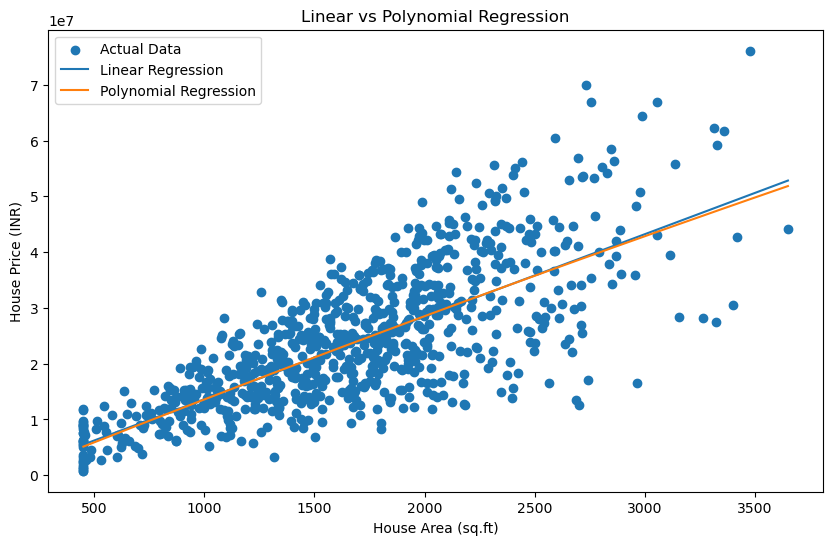

In [85]:
# Sort values for a smooth regression line
sorted_indices = X_test_simple["area_sqft"].argsort()

X_sorted = X_test_simple.iloc[sorted_indices]

# Linear predictions
linear_sorted = model.predict(X_sorted)

# Polynomial predictions
poly_sorted = poly_model.predict(X_sorted)


# Plot
plt.figure(figsize=(10, 6))

# Actual points
plt.scatter(
    X_test_simple["area_sqft"],
    y_test_simple,
    label="Actual Data"
)

# Linear line
plt.plot(
    X_sorted["area_sqft"],
    linear_sorted,
    label="Linear Regression"
)

# Polynomial curve
plt.plot(
    X_sorted["area_sqft"],
    poly_sorted,
    label="Polynomial Regression"
)

plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price (INR)")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()

In [86]:
# Linear Regression
linear_mse = mean_squared_error(y_test_simple, y_pred)
linear_mae = mean_absolute_error(y_test_simple, y_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test_simple, y_pred)


# Polynomial Regression
poly_mse = mean_squared_error(y_test_poly, y_pred_poly)
poly_mae = mean_absolute_error(y_test_poly, y_pred_poly)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(y_test_poly, y_pred_poly)


print("================================")
print("LINEAR VS POLYNOMIAL")
print("================================")

print("\nLinear Regression:")
print("MSE:", linear_mse)
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

print("\nPolynomial Regression:")
print("MSE:", poly_mse)
print("MAE:", poly_mae)
print("RMSE:", poly_rmse)
print("R²:", poly_r2)

LINEAR VS POLYNOMIAL

Linear Regression:
MSE: 66989260021849.47
MAE: 6294593.696131912
RMSE: 8184696.696997969
R²: 0.5625199587991578

Polynomial Regression:
MSE: 66962947122198.38
MAE: 6292394.561281691
RMSE: 8183089.094113444
R²: 0.5626917978136464


In [87]:
# Task 20 — Overfitting / Underfitting

In [88]:
# Linear Regression
linear_train_r2 = model.score(X_train_simple, y_train_simple)
linear_test_r2 = model.score(X_test_simple, y_test_simple)

# Polynomial Regression
poly_train_r2 = poly_model.score(X_train_poly, y_train_poly)
poly_test_r2 = poly_model.score(X_test_poly, y_test_poly)


print("================================")
print("OVERFITTING / UNDERFITTING")
print("================================")

print("\nLinear Regression:")
print("Training R²:", linear_train_r2)
print("Testing R²:", linear_test_r2)

print("\nPolynomial Regression:")
print("Training R²:", poly_train_r2)
print("Testing R²:", poly_test_r2)

OVERFITTING / UNDERFITTING

Linear Regression:
Training R²: 0.5723074839148459
Testing R²: 0.5625199587991578

Polynomial Regression:
Training R²: 0.5724674245504779
Testing R²: 0.5626917978136464


In [89]:
# TASK 21: Gradient Descent Concept

print("=" * 60)
print("TASK 21: GRADIENT DESCENT")
print("=" * 60)

print("\nWhat is Gradient Descent?")
print("Gradient Descent is an optimization algorithm.")
print("It is used to minimize the loss or cost function.")

print("\nHow does it work?")
print("1. Start with initial model parameters.")
print("2. Make predictions.")
print("3. Calculate the error.")
print("4. Calculate the gradient.")
print("5. Update the parameters.")
print("6. Repeat the process until the loss becomes small.")

print("\nUpdate Formula:")
print("New Parameter = Old Parameter - Learning Rate * Gradient")

print("\nLearning Rate:")
print("- Very small learning rate -> slow training")
print("- Very large learning rate -> unstable training")
print("- Suitable learning rate -> faster and stable convergence")

print("\nSimple Example:")
print("Imagine a ball on a hill.")
print("Gradient Descent moves the ball downhill step by step")
print("until it reaches the lowest point.")

print("\nCONCLUSION")
print("Gradient Descent helps a machine learning model find")
print("parameters that minimize prediction error.")

TASK 21: GRADIENT DESCENT

What is Gradient Descent?
Gradient Descent is an optimization algorithm.
It is used to minimize the loss or cost function.

How does it work?
1. Start with initial model parameters.
2. Make predictions.
3. Calculate the error.
4. Calculate the gradient.
5. Update the parameters.
6. Repeat the process until the loss becomes small.

Update Formula:
New Parameter = Old Parameter - Learning Rate * Gradient

Learning Rate:
- Very small learning rate -> slow training
- Very large learning rate -> unstable training
- Suitable learning rate -> faster and stable convergence

Simple Example:
Imagine a ball on a hill.
Gradient Descent moves the ball downhill step by step
until it reaches the lowest point.

CONCLUSION
Gradient Descent helps a machine learning model find
parameters that minimize prediction error.


In [90]:
# Task 22 — Batch Gradient Descent From Scratch

Batch Gradient Descent
Weight: 9374999.572412089
Bias: 23517754.36458705
Test MSE: 66989260086698.36


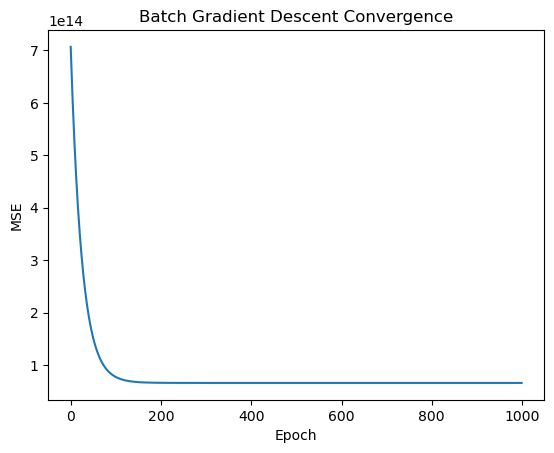

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


# ============================================
# LOAD DATA
# ============================================

df = pd.read_csv("house_price.csv")

X = df[["area_sqft"]].values
y = df["house_price_inr"].values


# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================
# SCALE X
# ============================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ============================================
# BATCH GRADIENT DESCENT
# ============================================

w = 0.0
b = 0.0

learning_rate = 0.01
epochs = 1000

n = len(X_train)

loss_history_batch = []


for epoch in range(epochs):

    # Prediction
    y_pred = w * X_train[:, 0] + b

    # Error
    error = y_pred - y_train

    # Cost
    cost = np.mean(error ** 2)

    loss_history_batch.append(cost)

    # Gradients
    dw = (2 / n) * np.sum(X_train[:, 0] * error)
    db = (2 / n) * np.sum(error)

    # Update parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db


print("Batch Gradient Descent")
print("Weight:", w)
print("Bias:", b)

# Test prediction
y_pred_batch = w * X_test[:, 0] + b

print("Test MSE:", mean_squared_error(y_test, y_pred_batch))


# Plot loss
plt.plot(loss_history_batch)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Batch Gradient Descent Convergence")
plt.show()

In [92]:
# Task 23 — Stochastic Gradient Descent (SGD)

SGD
Weight: 9418050.372874768
Bias: 23693599.817888506
Test MSE: 66744362919142.57


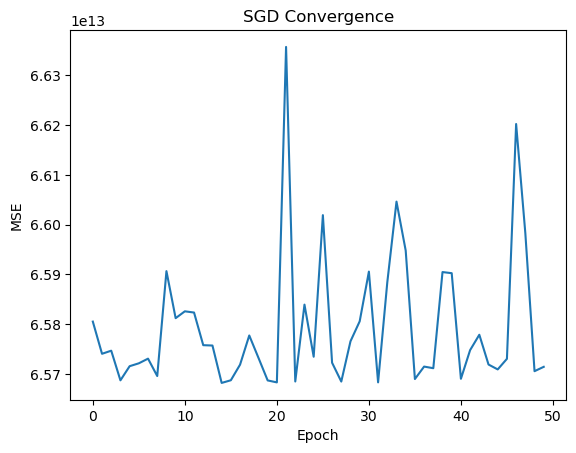

In [93]:
# ============================================
# STOCHASTIC GRADIENT DESCENT
# ============================================

w = 0.0
b = 0.0

learning_rate = 0.001
epochs = 50

loss_history_sgd = []

n = len(X_train)

for epoch in range(epochs):

    # Shuffle data
    indices = np.random.permutation(n)

    for i in indices:

        x_i = X_train[i, 0]
        y_i = y_train[i]

        # Prediction
        y_pred_i = w * x_i + b

        # Error
        error = y_pred_i - y_i

        # Gradients using ONE sample
        dw = 2 * x_i * error
        db = 2 * error

        # Update
        w = w - learning_rate * dw
        b = b - learning_rate * db

    # Calculate loss after epoch
    y_pred = w * X_train[:, 0] + b
    loss = np.mean((y_train - y_pred) ** 2)

    loss_history_sgd.append(loss)


print("SGD")
print("Weight:", w)
print("Bias:", b)

y_pred_sgd = w * X_test[:, 0] + b

print("Test MSE:", mean_squared_error(y_test, y_pred_sgd))


# Plot
plt.plot(loss_history_sgd)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("SGD Convergence")
plt.show()

In [94]:
#Task 24 — Mini-Batch Gradient Descent

Mini-Batch Gradient Descent
Weight: 9373514.739374701
Bias: 23513635.817036323
Test MSE: 66995964639243.71


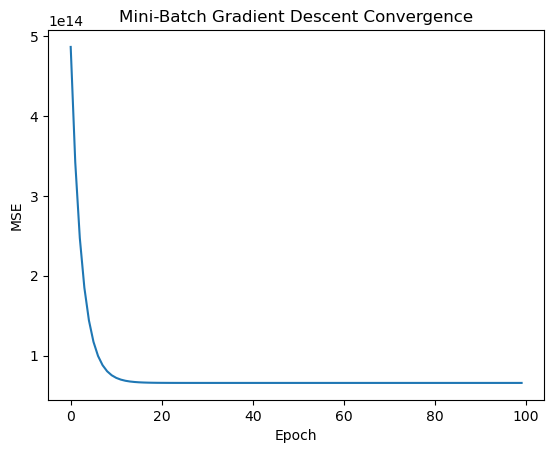

In [95]:
# ============================================
# MINI-BATCH GRADIENT DESCENT
# ============================================

w = 0.0
b = 0.0

learning_rate = 0.001
epochs = 100
batch_size = 32

loss_history_mini = []

n = len(X_train)


for epoch in range(epochs):

    # Shuffle data
    indices = np.random.permutation(n)

    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    # Mini-batches
    for start in range(0, n, batch_size):

        end = start + batch_size

        X_batch = X_shuffled[start:end, 0]
        y_batch = y_shuffled[start:end]

        # Prediction
        y_pred = w * X_batch + b

        # Error
        error = y_pred - y_batch

        # Number of samples in batch
        m = len(X_batch)

        # Gradients
        dw = (2 / m) * np.sum(X_batch * error)
        db = (2 / m) * np.sum(error)

        # Update
        w = w - learning_rate * dw
        b = b - learning_rate * db


    # Loss after epoch
    y_pred_train = w * X_train[:, 0] + b

    loss = np.mean(
        (y_train - y_pred_train) ** 2
    )

    loss_history_mini.append(loss)


print("Mini-Batch Gradient Descent")
print("Weight:", w)
print("Bias:", b)

y_pred_mini = w * X_test[:, 0] + b

print(
    "Test MSE:",
    mean_squared_error(y_test, y_pred_mini)
)


# Plot
plt.plot(loss_history_mini)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Mini-Batch Gradient Descent Convergence")
plt.show()

In [96]:
# Task 25 — Compare All Three Methods

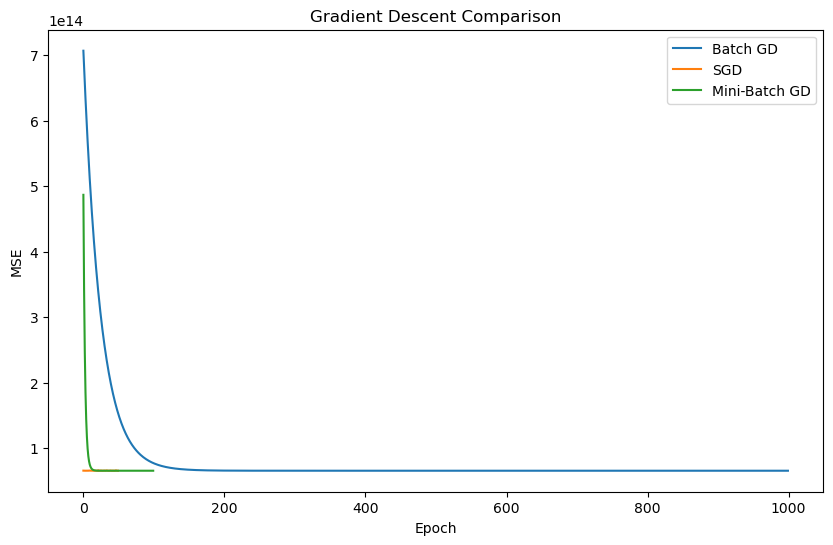

In [97]:
# ============================================
# COMPARE CONVERGENCE
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    loss_history_batch,
    label="Batch GD"
)

plt.plot(
    loss_history_sgd,
    label="SGD"
)

plt.plot(
    loss_history_mini,
    label="Mini-Batch GD"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Gradient Descent Comparison")
plt.legend()
plt.show()

In [98]:
# Task 26 — Analyze Bias and Variance

In [99]:
# ============================================
# PART H: BIAS-VARIANCE ANALYSIS
# ============================================

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score


# ============================================
# SIMPLE LINEAR REGRESSION
# ============================================

X_simple = df[["area_sqft"]]
y = df["house_price_inr"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(
    X_train_s,
    y_train_s
)

train_pred_s = simple_model.predict(X_train_s)
test_pred_s = simple_model.predict(X_test_s)

simple_train_r2 = r2_score(y_train_s, train_pred_s)
simple_test_r2 = r2_score(y_test_s, test_pred_s)


# ============================================
# MULTIPLE LINEAR REGRESSION
# ============================================

features = [
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "location_score",
    "age_years",
    "distance_city_km",
    "lot_size_sqft",
    "renovation_years_ago"
]

X_multi = df[features]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y,
    test_size=0.20,
    random_state=42
)

multi_model = LinearRegression()

multi_model.fit(
    X_train_m,
    y_train_m
)

train_pred_m = multi_model.predict(X_train_m)
test_pred_m = multi_model.predict(X_test_m)

multi_train_r2 = r2_score(y_train_m, train_pred_m)
multi_test_r2 = r2_score(y_test_m, test_pred_m)


# ============================================
# POLYNOMIAL REGRESSION
# ============================================

poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(
    X_train_s,
    y_train_s
)

train_pred_p = poly_model.predict(X_train_s)
test_pred_p = poly_model.predict(X_test_s)

poly_train_r2 = r2_score(y_train_s, train_pred_p)
poly_test_r2 = r2_score(y_test_s, test_pred_p)


# ============================================
# DISPLAY RESULTS
# ============================================

print("================================")
print("BIAS-VARIANCE ANALYSIS")
print("================================")

print("\nSimple Linear Regression")
print("Training R²:", simple_train_r2)
print("Testing R² :", simple_test_r2)

print("\nMultiple Linear Regression")
print("Training R²:", multi_train_r2)
print("Testing R² :", multi_test_r2)

print("\nPolynomial Regression")
print("Training R²:", poly_train_r2)
print("Testing R² :", poly_test_r2)

BIAS-VARIANCE ANALYSIS

Simple Linear Regression
Training R²: 0.5723074839148459
Testing R² : 0.5625199587991578

Multiple Linear Regression
Training R²: 0.9245941565730853
Testing R² : 0.917679546678781

Polynomial Regression
Training R²: 0.5724674245504779
Testing R² : 0.5626917978136464


In [100]:
# TASK 27: Effect of Model Complexity

print("=" * 60)
print("TASK 27: MODEL COMPLEXITY AND PREDICTION ERROR")
print("=" * 60)

print("\nWhat is Model Complexity?")
print("Model complexity describes how flexible or complicated")
print("a machine learning model is.")

print("\nLow Model Complexity:")
print("- Model may be too simple.")
print("- Important patterns may be missed.")
print("- Training error can be high.")
print("- Testing error can also be high.")
print("- This is called UNDERFITTING.")
print("- Underfitting is associated with HIGH BIAS.")

print("\nIncreasing Model Complexity:")
print("- Model can learn more complex patterns.")
print("- Training error usually decreases.")
print("- Bias generally decreases.")
print("- The model fits training data better.")

print("\nVery High Model Complexity:")
print("- Model may learn noise from training data.")
print("- Training error becomes very low.")
print("- Testing error may become high.")
print("- This is called OVERFITTING.")
print("- Overfitting is associated with HIGH VARIANCE.")

print("\nBIAS-VARIANCE TRADE-OFF")
print("Simple Model   -> High Bias    -> Underfitting")
print("Balanced Model -> Good Balance -> Good Generalization")
print("Complex Model  -> High Variance -> Overfitting")

print("\nCONCLUSION")
print("The best model is not necessarily the most complex model.")
print("The best model should perform well on unseen testing data.")

TASK 27: MODEL COMPLEXITY AND PREDICTION ERROR

What is Model Complexity?
Model complexity describes how flexible or complicated
a machine learning model is.

Low Model Complexity:
- Model may be too simple.
- Important patterns may be missed.
- Training error can be high.
- Testing error can also be high.
- This is called UNDERFITTING.
- Underfitting is associated with HIGH BIAS.

Increasing Model Complexity:
- Model can learn more complex patterns.
- Training error usually decreases.
- Bias generally decreases.
- The model fits training data better.

Very High Model Complexity:
- Model may learn noise from training data.
- Training error becomes very low.
- Testing error may become high.
- This is called OVERFITTING.
- Overfitting is associated with HIGH VARIANCE.

BIAS-VARIANCE TRADE-OFF
Simple Model   -> High Bias    -> Underfitting
Balanced Model -> Good Balance -> Good Generalization
Complex Model  -> High Variance -> Overfitting

CONCLUSION
The best model is not necessarily the 

In [101]:
## Task 28 — Identify the Best Bias-Variance Balance

In [102]:
# ============================================
# BIAS-VARIANCE GAP
# ============================================

simple_gap = simple_train_r2 - simple_test_r2
multi_gap = multi_train_r2 - multi_test_r2
poly_gap = poly_train_r2 - poly_test_r2

print("\n================================")
print("TRAIN-TEST R² GAP")
print("================================")

print("Simple Regression Gap:", simple_gap)
print("Multiple Regression Gap:", multi_gap)
print("Polynomial Regression Gap:", poly_gap)


TRAIN-TEST R² GAP
Simple Regression Gap: 0.009787525115688034
Multiple Regression Gap: 0.006914609894304258
Polynomial Regression Gap: 0.009775626736831522
